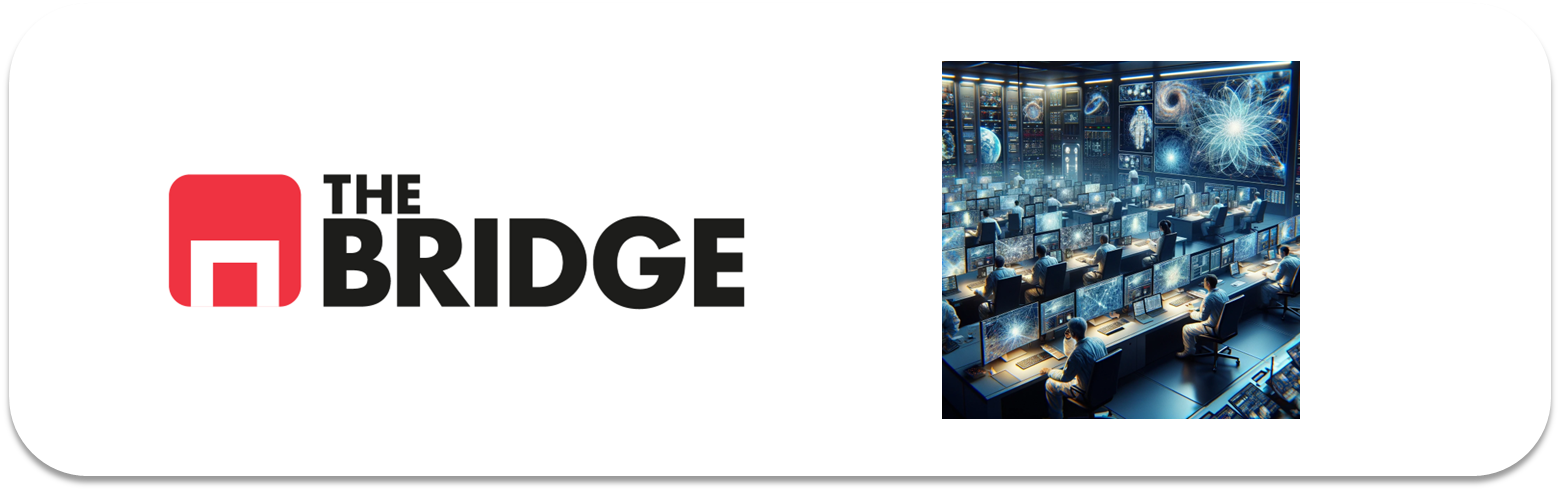

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [1]:
import os
import numpy as np
from PIL import Image

IMG_SIZE = (32, 32)

def load_images_from_dirs(dir_paths, img_size=(32, 32)):
    X, y = [], []
    for d in dir_paths:
        for fname in os.listdir(d):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            # Etiqueta desde el nombre
            fname_lower = fname.lower()
            if "cat" in fname_lower:
                label = 0
            elif "dog" in fname_lower:
                label = 1
            else:
                continue

            # Cargar imagen
            img = Image.open(os.path.join(d, fname)).convert("RGB")
            img = img.resize(img_size)
            X.append(np.array(img))
            y.append(label)

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="int32")
    return X, y

train_dirs = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]

test_dirs = ["data/github_test"]

X_train, y_train = load_images_from_dirs(train_dirs)
X_test, y_test = load_images_from_dirs(test_dirs)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(4000, 32, 32, 3) (4000,)
(1000, 32, 32, 3) (1000,)


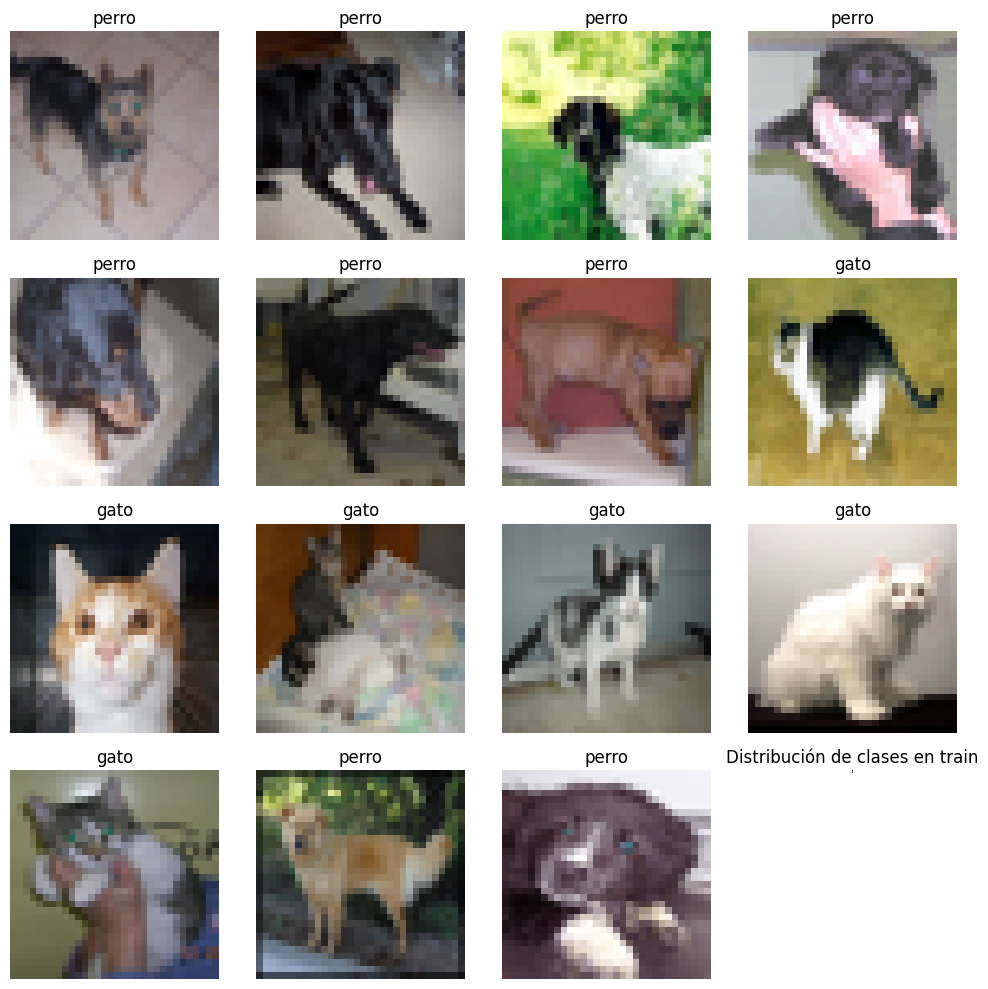

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

names = ["gato", "perro"]

def plot_samples(X, y, n=16):
    idx = np.random.choice(len(X), n, replace=False)
    n_cols = 4
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols*2.5, n_rows*2.5))
    for i, j in enumerate(idx):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(X[j])
        plt.axis('off')
        plt.title(names[y[j]])
    plt.tight_layout()

plot_samples(X_train, y_train, n=16)

sns.countplot(x=y_train)
plt.xticks([0,1], names)
plt.title("Distribución de clases en train");


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

input_shape = (32, 32, 3)

model = Sequential()

# Bloque 1
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Bloque 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Bloque 3 opcional (mejora mucho)
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Cabeza densa
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.summary()


c:\Users\César\OneDrive\Escritorio\DS\DS_ONLINE_CESAR\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,049 (2.36 MB)

 Trainable params: 618,049 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.6144 - loss: 0.6736 - val_accuracy: 0.0000e+00 - val_loss: 0.9106
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6250 - loss: 0.6592 - val_accuracy: 0.0000e+00 - val_loss: 0.7878
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6250 - loss: 0.6477 - val_accuracy: 0.0000e+00 - val_loss: 0.8145
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.6438 - loss: 0.6264 - val_accuracy: 0.2125 - val_loss: 0.8342
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6737 - loss: 0.6048 - val_accuracy: 0.4025 - val_loss: 0.7990
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6875 - loss: 0.5954 - val_accuracy: 0.3075 - val_loss: 0.8748
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6959 - loss: 0.5788 - val_accuracy: 0.2212 - val_loss: 0.9263


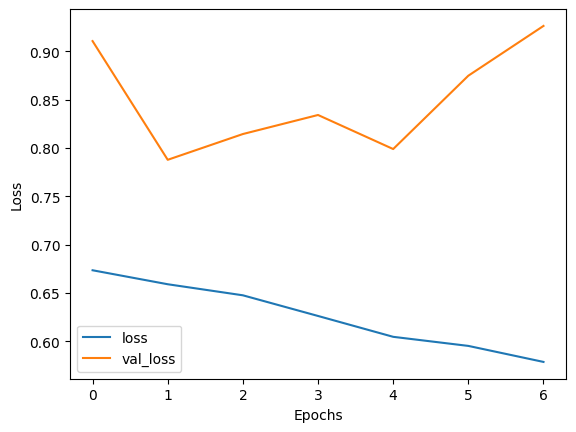

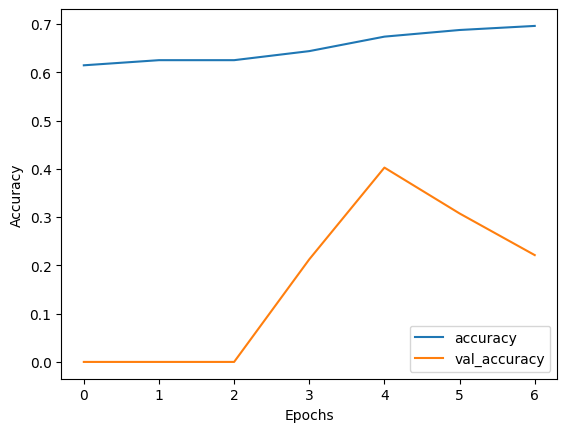

In [6]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df[['loss','val_loss']].plot()
plt.xlabel("Epochs")
plt.ylabel("Loss");

history_df[['accuracy','val_accuracy']].plot()
plt.xlabel("Epochs")
plt.ylabel("Accuracy");


Test loss: 0.6876746416091919
Test accuracy: 0.5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

        gato       0.50      1.00      0.67       500
       perro       0.00      0.00      0.00       500

    accuracy                           0.50      1000
   macro avg       0.25      0.50      0.33      1000
weighted avg       0.25      0.50      0.33      1000



c:\Users\César\OneDrive\Escritorio\DS\DS_ONLINE_CESAR\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\César\OneDrive\Escritorio\DS\DS_ONLINE_CESAR\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\César\OneDrive\Escritorio\DS\DS_ONLINE_CESAR\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


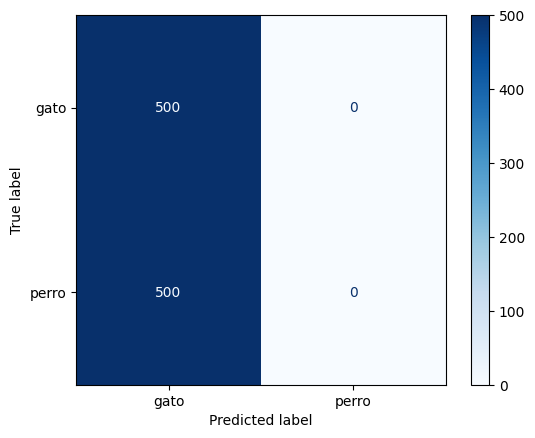

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_proba = model.predict(X_test).ravel()
y_pred = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=names))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=names,
    cmap='Blues'
);


In [8]:
mis_idx = np.where(y_pred != y_test)[0]

# perros → predicho gato
dog_to_cat_idx = mis_idx[(y_test[mis_idx] == 1) & (y_pred[mis_idx] == 0)]
dog_to_cat_conf = 1 - y_proba[dog_to_cat_idx]  # prob de gato

# gatos → predicho perro
cat_to_dog_idx = mis_idx[(y_test[mis_idx] == 0) & (y_pred[mis_idx] == 1)]
cat_to_dog_conf = y_proba[cat_to_dog_idx]  # prob de perro

def top_10_percent(idx_array, conf_array):
    if len(idx_array) == 0:
        return np.array([], dtype=int)
    n = max(1, int(0.1 * len(idx_array)))
    order = np.argsort(conf_array)[::-1]
    return idx_array[order[:n]]

top_dog_to_cat = top_10_percent(dog_to_cat_idx, dog_to_cat_conf)
top_cat_to_dog = top_10_percent(cat_to_dog_idx, cat_to_dog_conf)

print("Perros → gatos (difíciles):", len(top_dog_to_cat))
print("Gatos → perros (difíciles):", len(top_cat_to_dog))


Perros → gatos (difíciles): 50
Gatos → perros (difíciles): 0


No hay ejemplos para Gatos clasificados como perros (más difíciles)


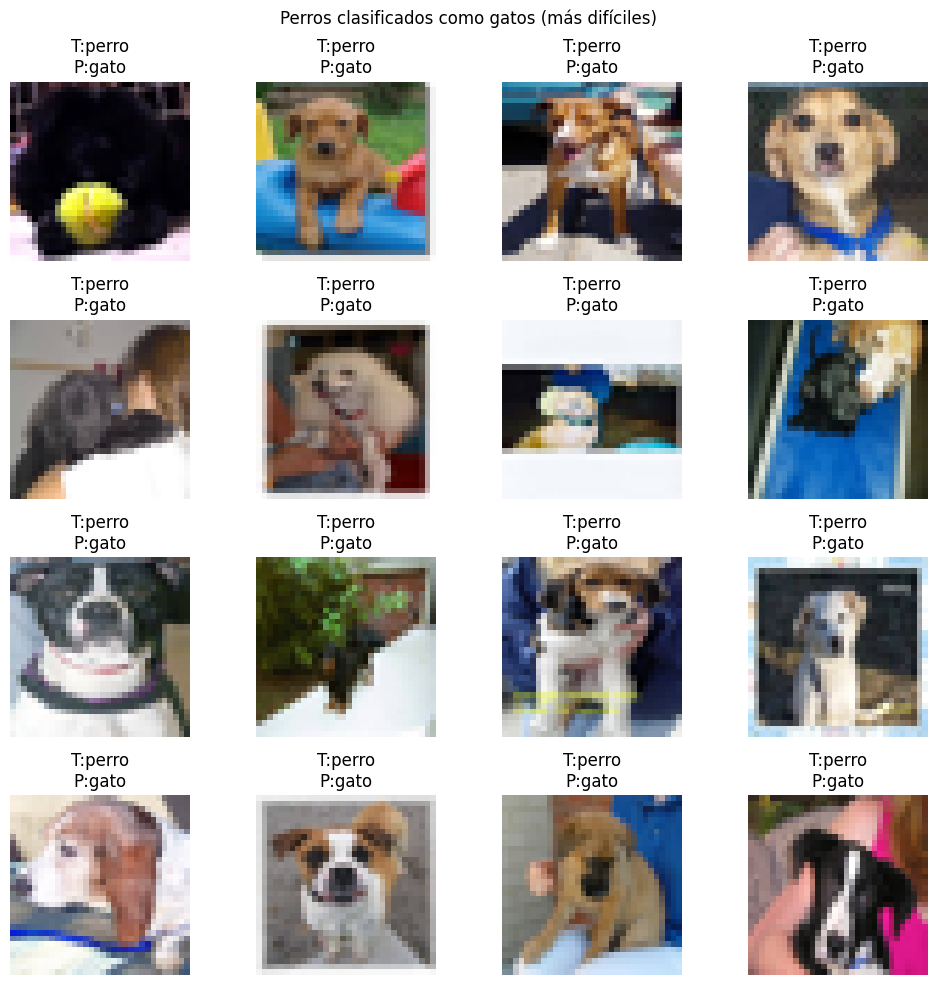

In [9]:
def plot_indices(X, y_true, y_pred, idx, title):
    n = min(len(idx), 16)
    if n == 0:
        print("No hay ejemplos para", title)
        return
    n_cols = 4
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols*2.5, n_rows*2.5))
    for i, j in enumerate(idx[:n]):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(X[j])
        plt.axis('off')
        plt.title(f"T:{names[y_true[j]]}\nP:{names[y_pred[j]]}")
    plt.suptitle(title)
    plt.tight_layout()

plot_indices(X_test, y_test, y_pred, top_dog_to_cat,
             "Perros clasificados como gatos (más difíciles)")
plot_indices(X_test, y_test, y_pred, top_cat_to_dog,
             "Gatos clasificados como perros (más difíciles)")


Extra: Entrenamiento con Image Augmentation

In [11]:
from sklearn.model_selection import train_test_split

# Split estratificado
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow(X_train2, y_train2, batch_size=64)
val_gen = datagen.flow(X_val, y_val, batch_size=64)

history_aug = model.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.5172 - loss: 0.6897 - val_accuracy: 0.5925 - val_loss: 0.6800
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.5825 - loss: 0.6723 - val_accuracy: 0.6112 - val_loss: 0.6585
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.5875 - loss: 0.6668 - val_accuracy: 0.6112 - val_loss: 0.6676
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.6028 - loss: 0.6583 - val_accuracy: 0.6150 - val_loss: 0.6521
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.6288 - loss: 0.6463 - val_accuracy: 0.6550 - val_loss: 0.6434
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.6581 - loss: 0.6270 - val_accuracy: 0.6775 - val_loss: 0.6065
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6503 - loss: 0.6222 - val_accuracy: 0.6538 - val_loss: 0.6251
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.6903 - loss: 0.6068 - val_accuracy: 0.